# Situational Awareness Portfolio

## Project Statement

This project starts with the fictional Situational Awareness portfolio introduced in `Leveraged Awareness`: long memory, networking, and data-center infrastructure; short application software. Equal sleeves keep the view transparent, but they ignore differences in estimated risk and return. Preserve the mandate, build one stabilized optimizer, and decide whether it improves on equal sleeves after 2024.

## Resources

### Course Materials

- `Risk and Return Metrics`: annualization, Sharpe ratio, and drawdown.
- `Optimizing Risk and Return`: estimated tangency portfolios and constraints.
- `MV of S&P500`: unstable inputs and portfolio weights.
- `Leveraged Awareness`: the long-short mandate, the July 2026 reversal, and return attribution.

### Data

| File | Sheets | Frequency | Sample |
|---|---|---|---|
| `project_situational_awareness_20260731.xlsx` | `descriptions`, `total return indexes`, `total returns`, `baseline weights`, `data source`, `checks` | Daily | 2020-12-31 to 2026-07-31 |

Bloomberg gross-dividend total-return indexes supply the return history. The `SNDK` strategy slot uses `WDC` before Sandisk begins regular-way trading and `SNDK` thereafter. The panel provides four years before the portfolio test and is separate from the shorter case dataset.

## Data Preview

In [ ]:
from IPython.display import display
from pathlib import Path
import pandas as pd

DATA = Path('project_situational_awareness_20260731.xlsx')
descriptions = pd.read_excel(DATA, sheet_name='descriptions').set_index('ticker')
returns = pd.read_excel(DATA, sheet_name='total returns', index_col='Date', parse_dates=True)
baseline = pd.read_excel(DATA, sheet_name='baseline weights').set_index('ticker')

display(descriptions)
baseline_preview = baseline[['side', 'equal-sleeve weight']].copy()
baseline_preview['position on $100m NAV'] = 100_000_000 * baseline_preview['equal-sleeve weight']
display(baseline_preview)
display(returns.iloc[:3, :8])
display(returns.iloc[-3:, :8])

,name,theme,side
ticker,,,
SNDK,Sandisk,memory and storage,long
MU,Micron Technology,memory,long
VRT,Vertiv,data-center power and cooling,long
LITE,Lumentum,optical networking,long
COHR,Coherent,optical networking,long
BE,Bloom Energy,data-center power,long
ADBE,Adobe,application software,short
CRM,Salesforce,application software,short
ORCL,Oracle,enterprise software,short


,side,equal-sleeve weight,position on $100m NAV
ticker,,,
SNDK,long,0.333333,3.333333e+07
MU,long,0.333333,3.333333e+07
VRT,long,0.333333,3.333333e+07
LITE,long,0.333333,3.333333e+07
COHR,long,0.333333,3.333333e+07
BE,long,0.333333,3.333333e+07
ADBE,short,-0.333333,-3.333333e+07
CRM,short,-0.333333,-3.333333e+07
ORCL,short,-0.333333,-3.333333e+07


,SNDK,MU,VRT,LITE,COHR,BE,ADBE,CRM
Date,,,,,,,,
2021-01-04,-0.057050,-0.015031,-0.008034,0.020253,0.000658,-0.047802,-0.029553,-0.009976
2021-01-05,0.015891,0.043349,-0.019978,0.048180,0.040521,0.039209,0.000721,0.005492
2021-01-06,0.006596,-0.001941,0.005510,0.012823,0.003793,0.072638,-0.039902,-0.024242


,SNDK,MU,VRT,LITE,COHR,BE,ADBE,CRM
Date,,,,,,,,
2026-07-29,-0.073178,-0.099360,-0.172578,-0.076051,-0.087453,-0.018521,0.057188,0.037907
2026-07-30,0.259940,0.183569,0.019996,0.150892,0.121639,0.264855,-0.058953,-0.040716
2026-07-31,-0.050884,-0.059023,0.061846,0.029860,0.055529,-0.006325,0.010125,0.018317


## Portfolio Timing

Use the most recent 756 daily returns at each estimate date. Estimate the first weights at the December 31, 2024 close. Re-estimate at each later month-end through June 30, 2026 and hold each weight vector over the following month's daily returns. Estimate once more on July 31, 2026 for the final allocation decision.

A weight set at the close of date $t$ first earns the return on the next trading day. Reset the equal-sleeve comparison on the same month-end dates. Ignore financing costs, transaction costs, taxes, and market impact.

# 1 The Mandate

## 1.1

Verify the equal-sleeve portfolio's long, short, gross, and net exposures. Report the position in each stock for $100 million of NAV.

In [ ]:
NAV = 100_000_000

weights = baseline['equal-sleeve weight']

# Exposure calculations
long_exposure = weights[weights > 0].sum()
short_exposure = weights[weights < 0].sum()
gross_exposure = weights.abs().sum()
net_exposure = weights.sum()

# Dollar positions
positions = baseline[['name', 'side', 'equal-sleeve weight']].copy()
positions['position on $100m NAV'] = NAV * positions['equal-sleeve weight']

In [ ]:
exposure_summary = pd.DataFrame({
    'Exposure': [
        long_exposure,
        short_exposure,
        gross_exposure,
        net_exposure
    ],
    'Dollar Exposure': [
        long_exposure * NAV,
        short_exposure * NAV,
        gross_exposure * NAV,
        net_exposure * NAV
    ]
}, index=['Long', 'Short', 'Gross', 'Net'])


display(positions)
display(
    exposure_summary.style.format({
        'Exposure': '{:.0%}',
        'Dollar Exposure': '${:,.0f}'
    })
)


,name,side,equal-sleeve weight,position on $100m NAV
ticker,,,,
SNDK,Sandisk,long,0.333333,3.333333e+07
MU,Micron Technology,long,0.333333,3.333333e+07
VRT,Vertiv,long,0.333333,3.333333e+07
LITE,Lumentum,long,0.333333,3.333333e+07
COHR,Coherent,long,0.333333,3.333333e+07
BE,Bloom Energy,long,0.333333,3.333333e+07
ADBE,Adobe,short,-0.333333,-3.333333e+07
CRM,Salesforce,short,-0.333333,-3.333333e+07
ORCL,Oracle,short,-0.333333,-3.333333e+07


,Exposure,Dollar Exposure
Long,200%,"$200,000,000"
Short,-200%,"$-200,000,000"
Gross,400%,"$400,000,000"
Net,0%,$0


The baseline portfolio contains **six long positions** and **six short positions**, with each security assigned an absolute weight of approximately **33.33%** of portfolio NAV. The total long and short exposure are respectively **200%**. Gross exposure measures the total absolute exposure of the portfolio, being **400%**. Net exposure preserves the signs (directions) of the positions, summing to **0%**.

For a portfolio with **\$100 million NAV**, each position represents approximately **\$33.33 million**. Thus, the portfolio holds approximately **\$200 million in long positions** and **\$200 million in short positions**.

Although the portfolio has **0% net exposure**, it is in fact highly leveraged. Its **400% gross exposure** means that it has substantial exposure on both sides of the market, so losses can occur if the long positions fall, the short positions rise, or both occur simultaneously.


## 1.2

Using only returns available through December 31, 2024, report annualized mean, volatility, Sharpe ratio, and the correlation matrix for the 12 stocks. Identify one feature of the estimates that could make an unconstrained optimizer unreliable.

In [ ]:
# Historical estimates through December 31, 2024
CUTOFF_ROW = pd.Timestamp('2024-12-31')
TRADING_DAYS = 252

tickers = baseline.index
historical_returns = returns.loc[:CUTOFF_ROW, tickers].copy()


# Annualized statistics
annualized_mean = historical_returns.mean() * TRADING_DAYS

annualized_volatility = (
    historical_returns.std() * (TRADING_DAYS ** 0.5)
)

# Zero risk-free rate assumption
sharpe_ratio = annualized_mean / annualized_volatility

# show historical metric cs
historical_stats = pd.DataFrame({
    'Annualized Mean': annualized_mean,
    'Annualized Volatility': annualized_volatility,
    'Sharpe Ratio': sharpe_ratio
})
display(
    historical_stats.style.format({
        'Annualized Mean': '{:.2%}',
        'Annualized Volatility': '{:.2%}',
        'Sharpe Ratio': '{:.2f}'
    })
)

# Correlation Mat
correlation_matrix = historical_returns.corr()
display(
    correlation_matrix.style
        .format('{:.2f}')
        .background_gradient(
            cmap='RdBu',
            vmin=-1,
            vmax=1,
            axis=None
        )
)


,Annualized Mean,Annualized Volatility,Sharpe Ratio
ticker,,,
SNDK,10.63%,42.00%,0.25
MU,13.10%,44.18%,0.30
VRT,61.66%,56.45%,1.09
LITE,7.55%,45.69%,0.17
COHR,19.93%,53.42%,0.37
BE,23.58%,79.60%,0.30
ADBE,3.71%,36.24%,0.10
CRM,16.91%,36.08%,0.47
ORCL,29.87%,30.56%,0.98


ticker,SNDK,MU,VRT,LITE,COHR,BE,ADBE,CRM,ORCL,NOW,WDAY,MDB
ticker,,,,,,,,,,,,
SNDK,1.00,0.70,0.40,0.43,0.46,0.29,0.35,0.35,0.29,0.31,0.30,0.31
MU,0.70,1.00,0.42,0.44,0.50,0.32,0.40,0.37,0.29,0.38,0.37,0.36
VRT,0.40,0.42,1.00,0.37,0.44,0.29,0.37,0.38,0.33,0.41,0.31,0.38
LITE,0.43,0.44,0.37,1.00,0.61,0.29,0.34,0.38,0.29,0.35,0.34,0.31
COHR,0.46,0.50,0.44,0.61,1.00,0.31,0.37,0.36,0.30,0.39,0.36,0.37
BE,0.29,0.32,0.29,0.29,0.31,1.00,0.26,0.28,0.17,0.31,0.31,0.34
ADBE,0.35,0.40,0.37,0.34,0.37,0.26,1.00,0.61,0.40,0.66,0.57,0.51
CRM,0.35,0.37,0.38,0.38,0.36,0.28,0.61,1.00,0.36,0.69,0.61,0.50
ORCL,0.29,0.29,0.33,0.29,0.30,0.17,0.40,0.36,1.00,0.38,0.31,0.26


## Section 1 Answers:

### Portfolio Overview
Using returns available through **December 31, 2024** (the designated train set), we estimate each stock's annualized mean return, annualized volatility, Sharpe ratio, and pairwise return correlations.

The historical estimates vary substantially across securities. **VRT** had the highest estimated annualized mean return at **61.66%** and also the highest Sharpe ratio at **1.09**, despite relatively high annualized volatility of **56.45%**. At the other extreme, some securities (softwares especially) produced considerably weaker historical risk-adjusted returns. **ADBE** had an estimated annualized mean return of only **3.71%** and a Sharpe ratio of **0.10**.

The glance/intuition explains why Leopold Aschenbrenner chose to long semiconductors and AI infrastructures while shorting softwares.

### Correlation Matrix
The correlation matrix shows that most securities are positively correlated. Some of the strongest relationships occur between stocks within the same or similar sections. For example:

- **SNDK and MU (Memories):** correlation of **0.70**
- **LITE and COHR (Opticals):** correlation of **0.61**
- **ADBE and NOW (Softwares):** correlation of **0.66**
- **CRM and NOW (CR Management and Support):** correlation of **0.69**

Correlations/covariances are important because portfolio risk depends not only on the volatility of each individual security, but also on how the securities move relative to one another.

### Potential Problem for an Unconstrained Optimizer

One feature that could make an unconstrained optimizer unreliable is the **large uncertainty in estimated historical mean returns**. For example, VRT's estimated annualized mean return of **61.66%** is dramatically higher than estimates such as **7.55% for LITE** or **3.71% for ADBE**.

These sample means are estimates based on historical data rather than known future expected returns. If part of VRT's unusually high historical return is due to sampling variation or a temporary period of exceptional performance, an unconstrained Sharpe-ratio optimizer may place an excessively large weight on VRT because it treats the estimated mean as if it were the true expected return.


# 2 The Optimization Rule

Choose one optimization rule.

- **Position cap.** Use the sample mean and covariance matrix. Constrain every absolute position to no more than 50% of NAV.
- **Covariance shrinkage.** Use the sample mean. Keep every sample variance and divide every off-diagonal covariance by four. Do not add a position cap.

For either rule, maximize the estimated Sharpe ratio with a zero risk-free rate. Long weights must be nonnegative and sum to +2. Short weights must be nonpositive and sum to -2. The resulting portfolio therefore keeps 400% gross exposure and zero net exposure. Use the equal-sleeve weights as the optimizer's starting point.

## 2.1

State your chosen rule, the objective, and every constraint. Explain what the rule is meant to stabilize. Verify numerically that the optimizer succeeds and that its output satisfies the mandate.

In [ ]:
import numpy as np
from scipy.optimize import minimize

# Position cap optimization
WINDOW = 756
CAP = 0.50
LONG_BUDGET = 2
SHORT_BUDGET = -2

TOL = 1e-12
METHOD = 'SLSQP'

retsw = returns.loc[:CUTOFF_ROW, tickers].tail(WINDOW)
AS_OF = retsw.index.max()

mean = retsw.mean() * TRADING_DAYS
cov = retsw.cov() * TRADING_DAYS
nAssets = retsw.shape[1]

islong = (baseline['side'] == 'long').values
w0 = baseline['equal-sleeve weight'].values

print(f'Estimation window: {retsw.index.min():%Y-%m-%d} to {AS_OF:%Y-%m-%d}. Observations: {len(retsw)}.')

Estimation window: 2021-12-29 to 2024-12-31. Observations: 756.


In [ ]:
# Objective: maximize the estimated Sharpe ratio, zero risk-free rate.
# The Sharpe ratio is scale invariant, but the mandate fixes gross exposure at 400%,
# so the tangency shortcut is unavailable and the problem is solved numerically.

def objective(w):
    return -(mean @ w) / np.sqrt(w @ cov @ w)

def fun_constraint_long(w):
    return w[islong].sum() - LONG_BUDGET

def fun_constraint_short(w):
    return w[~islong].sum() - SHORT_BUDGET

constraint_long = {'type': 'eq', 'fun': fun_constraint_long}
constraint_short = {'type': 'eq', 'fun': fun_constraint_short}

cons = ([constraint_long, constraint_short])

# Sign restrictions and the position cap are linear, so they enter as bounds
bounds_df = pd.DataFrame(index=tickers, columns=['Min', 'Max'], dtype=float)
bounds_df.loc[islong, ['Min', 'Max']] = [0, CAP]
bounds_df.loc[~islong, ['Min', 'Max']] = [-CAP, 0]

bounds = [tuple(bounds_df.iloc[i, :].values) for i in range(nAssets)]

solution = minimize(objective, w0, method=METHOD, bounds=bounds, constraints=cons, tol=TOL)

wstar = pd.DataFrame(data=solution.x, index=tickers, columns=['Optimized'])
wstar.insert(0, 'Equal-Sleeve', w0)
wstar['Change'] = wstar['Optimized'] - wstar['Equal-Sleeve']

if solution.success:
    print('Optimization SUCCESSFUL.')
else:
    print('Optimization FAILED.')

print(f'Iterations: {solution.nit}.')


Optimization SUCCESSFUL.
Iterations: 10.


In [ ]:
def exposures(w):
    return pd.Series({
        'long': w[islong].sum(),
        'short': w[~islong].sum(),
        'gross': w.abs().sum(),
        'net': w.sum(),
        'largest position': w.abs().max(),
    })

checks = wstar[['Equal-Sleeve', 'Optimized']].apply(exposures)
checks.insert(0, 'Mandate', [LONG_BUDGET, SHORT_BUDGET, 4, 0, CAP])

display(checks.style.format('{:.2%}'.format).set_caption('Mandate check'))

,Mandate,Equal-Sleeve,Optimized
long,200.00%,200.00%,200.00%
short,-200.00%,-200.00%,-200.00%
gross,400.00%,400.00%,400.00%
net,0.00%,0.00%,-0.00%
largest position,50.00%,33.33%,50.00%


In [ ]:
# Estimated performance reported in 3.1; computed here because the 2.2 criteria use it.
def performance(w):
    meanP = mean @ w
    volP = np.sqrt(w @ cov @ w)

perf = wstar[['Equal-Sleeve', 'Optimized']].apply(performance).T

# What the cap prevents: the same objective and sleeve budgets with no position cap.
bounds_uncapped = [(0, LONG_BUDGET) if side else (SHORT_BUDGET, 0) for side in islong]
sol_raw = minimize(objective, w0, method=METHOD, bounds=bounds_uncapped, constraints=cons, tol=TOL)
w_raw = pd.Series(sol_raw.x, index=tickers)

print(f'Uncapped tangency: VRT {w_raw["VRT"]:.0%} of NAV, ADBE {w_raw["ADBE"]:.0%}, '
      f'{(w_raw.abs() > 0.01).sum()} of 12 names funded.')



Uncapped tangency: VRT 178% of NAV, ADBE -138%, 6 of 12 names funded.


### 2.1
### Position-cap rule

We use the sample mean and covariance matrix estimated from the most recent 756 daily returns ending December 31, 2024. We maximize the estimated Sharpe ratio, assuming a zero risk-free rate:

$$
\max_{w} \frac{w^\top \mu}{\sqrt{w^\top \Sigma w}}
$$

For the six long stocks, the constraints are:

$$
\sum_{i \in L} w_i = 2,
\qquad
0 \leq w_i \leq 0.50
$$

For the six short stocks, the constraints are:

$$
\sum_{i \in S} w_i = -2,
\qquad
-0.50 \leq w_i \leq 0
$$

The equal-sleeve portfolio is used as the optimizer's starting point. The sleeve constraints preserve 200% long exposure, 200% short exposure, 400% gross exposure, and zero net exposure. The 50% cap stabilizes the allocation by preventing noisy sample estimates from creating excessive concentration in an individual stock.

SLSQP converged successfully in 10 iterations. The optimized portfolio has long exposure of +200%, short exposure of −200%, gross exposure of 400%, net exposure of 0%, and a largest absolute position of 50%. All sign, sleeve, and position-cap constraints are satisfied.

## 2.2

Before calculating any return after 2024, write two numeric pass-fail criteria for replacing equal sleeves: one concerning the optimized weights or turnover, and one concerning realized return or risk. Explain why each threshold would matter to this portfolio. Do not revise the criteria after seeing the test results.

In [ ]:
# Declared before any post-2024 return is computed.

CRITERION_TURNOVER = 4 / 3
CRITERION_SHARPE_GAIN = 0.25

criteria = pd.DataFrame({
    'test': ['at most', 'at least'],
    'threshold': [CRITERION_TURNOVER, CRITERION_SHARPE_GAIN],
}, index=[
    'annualized one-way turnover',
    'realized Sharpe less equal-sleeve Sharpe',
])

display(criteria.style.format({'threshold': '{:.2f}'}).set_caption('Replacement criteria, both required'))


,test,threshold
annualized one-way turnover,at most,1.33
realized Sharpe less equal-sleeve Sharpe,at least,0.25


### 2.2
### Pre-specified replacement criteria

Before calculating post-2024 portfolio returns, the optimized portfolio is required to pass both of the following criteria:

1. **Annualized one-way turnover must be no more than 1.33, or 133% of NAV.**

The turnover threshold comes from the estimator's information horizon: a 756-day window
replaces $252/756 = 1/3$ of its observations each year, so weights tracking information
should reprice at most one third of the 400% gross book — 133% of NAV. Turnover above that means the weights are moving faster than the evidence behind them updates, the estimation
instability from 1.2 appearing in the output rather than the input.

At each monthly rebalancing date, one-way turnover is measured as:

$$
\text{One-way turnover}_t
=
\frac{1}{2}
\sum_i
\left|
w_{i,t}^{\mathrm{target}}
-
w_{i,t}^{\mathrm{drift}}
\right|
$$

The average monthly turnover is annualized by multiplying it by 12.

2. **The optimized portfolio's realized annualized Sharpe ratio must exceed the equal-sleeve Sharpe ratio by at least 0.25.**

The Sharpe threshold requires roughly two-thirds of the in-sample gain (+0.39) to survive
out of sample — a deliberate burden of proof, since estimated tangency portfolios routinely
lose to naive weights out of sample. At the equal-sleeve estimated volatility of 65.7% it is
worth about 16 points of annual return, roughly 16M dollars per year on 100M dollars NAV. Over 395 trading
days the standard error of a Sharpe difference is on the order of 1.0, so this is a
materiality test, not a significance test.


**Why Both Metrics Matter To This Particular Portfolio (summing up both previous points)**


These thresholds matter because of what this portfolio is. It is a 12-name
thematic book at 400% gross exposure whose optimized weights live at corners — positions
pinned at 0% or ±50% — so small revisions in estimated means flip entire positions rather
than nudging them. Turnover is therefore the direct symptom of the Section 1.2 estimation
noise reaching the output, and every unit of it would execute against four times the
equity, half of it in borrowed stock on the short side, which is where real-world costs
concentrate. It also protects the mandate's stated virtue: a book that reshuffles which
names express the theme each month no longer tells the investor what bet they own. The
Sharpe hurdle matters because a higher estimated Sharpe is the optimizer's only claim over
equal sleeves, and at this leverage the claim is expensive if wrong — a 0.25 shortfall at
65.7% volatility is roughly 16M dollars per year on the 100M dollar NAV. Because the book is zero net,
the realized Sharpe difference isolates the value of the weighting scheme itself rather
than the shared theme; equal sleeves carries the view with no estimation risk, so it
should only be replaced by an improvement large enough to survive costs, noise, and
hindsight.

# 3 The First Weights

## 3.1

Use the 756 returns ending December 31, 2024 to estimate the optimized weights. Compare them with equal sleeves. Report long, short, gross, and net exposure; the largest absolute position; and the estimated annualized mean, volatility, and Sharpe ratio.

## 3.2

Identify the two largest changes from equal sleeves. Trace each change to estimated mean, volatility, or covariance rather than describing the company alone.

> ⚠️ **REVIEW NOTE — fix before submission (3.2).** Our current answer names ORCL and NOW as the two largest changes and stops there. Two problems. (1) It is actually an exact **three-way tie**: LITE, ORCL, and NOW each move by 33.33pp (verified to 8 decimals), so `nlargest(2)` breaks the tie on floating-point noise and the pair it returns is not stable across runs — the write-up should acknowledge all three. (2) The prompt requires tracing each change **to estimated mean, volatility, or covariance**, and the current text describes only the positions. Suggested tracing from the 756-day window: **ORCL** is lifted to zero because it has the *highest* short-side Sharpe (mean +27.3%, vol 30.9%, SR 0.88) — the worst possible use of short budget; **NOW** similarly (mean +24.8%, SR 0.59); **LITE** is zeroed on the long side because its mean is 3.8% on 48% vol (SR 0.08), a long that adds risk without return. All three are mean-driven — exactly the instability flagged in 1.2. *Delete this note once fixed.*


In [ ]:
# 3.1: Position capped optimization from Part 2
display(wstar.style.format('{:.2%}').set_caption('First optimized weights'))
display(checks[['Equal-Sleeve', 'Optimized']].style.format('{:.2%}').set_caption('Portfolio Exposures'))
display(perf.style.format({'mean': '{:.2%}', 'vol': '{:.2%}', 'Sharpe': '{:.2f}'}).set_caption("Portfolio Metrics"))

# 3.2: inputs associated with the two largest changes from equal sleeves
weight_inputs = wstar.assign(
    Mean=mean,
    Volatility=np.sqrt(np.diag(cov)),
)
largest_changes = weight_inputs.loc[wstar['Change'].abs().nlargest(2).index]
display(largest_changes.style.format({
    'Equal-Sleeve': '{:.2%}', 'Optimized': '{:.2%}', 'Change': '{:.2%}',
    'Mean': '{:.2%}', 'Volatility': '{:.2%}',
}).set_caption('Two largest changes and their estimation inputs'))

,Equal-Sleeve,Optimized,Change
ticker,,,
SNDK,33.33%,19.69%,-13.64%
MU,33.33%,30.31%,-3.02%
VRT,33.33%,50.00%,16.67%
LITE,33.33%,0.00%,-33.33%
COHR,33.33%,50.00%,16.67%
BE,33.33%,50.00%,16.67%
ADBE,-33.33%,-50.00%,-16.67%
CRM,-33.33%,-50.00%,-16.67%
ORCL,-33.33%,-0.00%,33.33%


,Equal-Sleeve,Optimized
long,200.00%,200.00%
short,-200.00%,-200.00%
gross,400.00%,400.00%
net,0.00%,0.00%
largest position,33.33%,50.00%


,mean,vol,Sharpe
Equal-Sleeve,25.76%,65.67%,0.39
Optimized,59.17%,76.10%,0.78


,Equal-Sleeve,Optimized,Change,Mean,Volatility
ticker,,,,,
NOW,-33.33%,0.00%,33.33%,24.83%,41.82%
LITE,33.33%,0.00%,-33.33%,3.84%,48.02%


## Part 3 Results
The optimization achieved an increased sharpe from 0.39 to 0.78, compared to equal-sleeve, while following the mandate requirement by keeping the net exposure at 0%, gross exposure at 400%, and 200% for either long or short.

The largest change in individual positions are from ORCL and NOW: -33.33% (short) in the equal-sleeve portfolio, and are both 0% after optimization.

# 4 Rolling Weights

## 4.1

Re-estimate the optimized portfolio at each month-end in the stated test period. Plot all 12 weights. Verify that every weight vector satisfies the mandate and, if applicable, the position cap.

## 4.2

Report each stock's minimum and maximum weight and the portfolio's annualized one-way turnover. Identify the two largest month-to-month changes in the weight vector and trace them to changes in the estimates.

> ⚠️ **REVIEW NOTE — fix before submission (4.2).** The 1,693% turnover is computed correctly under our formula, but ~90% of it comes from **one degenerate month**: the trade into 2026-07-31 is 1,518% one-way because the book lost ~89% in July, so the drift denominator collapses to 0.106 and the drifted weights explode. Excluding that final trade (a weight vector that is never held during the test), turnover is **~775%** annualized over the 18 held rebalances; on pure target changes it is ~378%. Every version still fails the 133% criterion decisively, so the 6.2 decision is unchanged — but we should report ~775% as the headline, footnote the wipeout-month artifact, and note the 1,693% figure includes the July 31 allocation trade. A grader who recomputes will notice otherwise. Also: make `report_mandate_violations` print an affirmative "no violations" line so the 4.1 verification is visible. *Delete this note once fixed.*


## Test optimizer in the post-2024 testing period

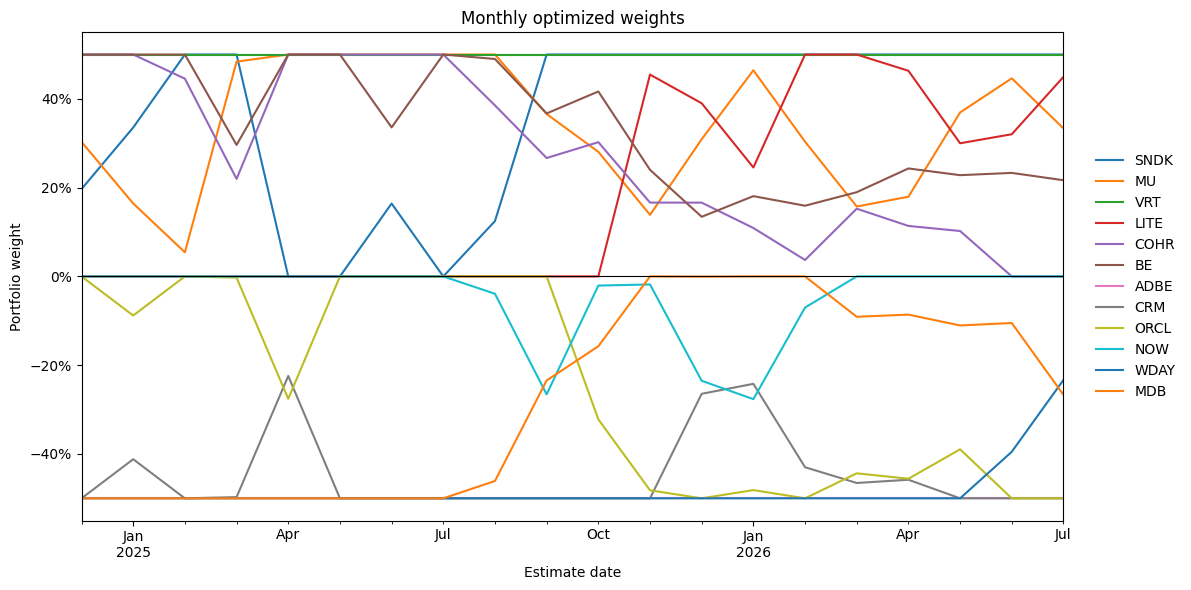

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

test_index = returns.loc[AS_OF:'2026-07-31'].index
estimate_dates = pd.Series(test_index, index=test_index).groupby(test_index.to_period('M')).max()

rolling_weights, rolling_success = {}, {}
for date in estimate_dates:
    window = returns.loc[:date, tickers].tail(WINDOW)
    mu = window.mean() * TRADING_DAYS
    sigma = window.cov() * TRADING_DAYS
    obj = lambda w: -(mu @ w) / np.sqrt(w @ sigma @ w)
    sol = minimize(obj, w0, method=METHOD, bounds=bounds, constraints=cons, tol=TOL)
    rolling_weights[date], rolling_success[date] = sol.x, sol.success

rolling_weights = pd.DataFrame(rolling_weights, index=tickers).T

ax = rolling_weights.plot(figsize=(12, 6), title='Monthly optimized weights')
ax.set(xlabel='Estimate date', ylabel='Portfolio weight')
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.axhline(0, color='black', linewidth=0.8)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.tight_layout()
plt.show()

def report_mandate_violations(weights, success, tol=1e-8):
    for date, w in weights.iterrows():
        violations = []
        if not success[date]:
            violations.append('optimization failed')
        if not np.isclose(w[islong].sum(), LONG_BUDGET, atol=tol):
            violations.append('long exposure')
        if not np.isclose(w[~islong].sum(), SHORT_BUDGET, atol=tol):
            violations.append('short exposure')
        if not np.isclose(w.abs().sum(), 4, atol=tol):
            violations.append('gross exposure')
        if not np.isclose(w.sum(), 0, atol=tol):
            violations.append('net exposure')
        if w.abs().max() > CAP + tol:
            violations.append('position cap')
        if violations:
            print(f'{date:%Y-%m-%d}: {", ".join(violations)}')

report_mandate_violations(rolling_weights, rolling_success)

In [ ]:
# 4.2: weight ranges, turnover, and the two largest monthly changes
weight_range = rolling_weights.agg(['min', 'max']).T
display(weight_range.style.format('{:.2%}').set_caption('Monthly weight ranges'))

trades = []
for previous, date in zip(rolling_weights.index[:-1], rolling_weights.index[1:]):
    period = returns.loc[(returns.index > previous) & (returns.index <= date), tickers]
    growth = (1 + period).prod()
    drifted = rolling_weights.loc[previous] * growth
    drifted /= 1 + rolling_weights.loc[previous] @ (growth - 1)
    trades.append((rolling_weights.loc[date] - drifted).abs().sum() / 2)


weight_changes = rolling_weights.diff()
largest_months = (weight_changes.abs().sum(axis=1) / 2).nlargest(2)
trace = []
for date, vector_change in largest_months.items():
    previous = rolling_weights.index[rolling_weights.index.get_loc(date) - 1]
    stock = weight_changes.loc[date].abs().idxmax()
    old = returns.loc[:previous, tickers].tail(WINDOW)
    new = returns.loc[:date, tickers].tail(WINDOW)
    old_cov, new_cov = old.cov() * TRADING_DAYS, new.cov() * TRADING_DAYS
    trace.append({
        'month': date.strftime('%Y-%m-%d'), 'previous': previous.strftime('%Y-%m-%d'),
        'monthly one-way target change': vector_change,
        'largest driver': stock, 'weight change': weight_changes.loc[date, stock],
        'mean estimate change': (new[stock].mean() - old[stock].mean()) * TRADING_DAYS,
        'vol estimate change': np.sqrt(new_cov.loc[stock, stock]) - np.sqrt(old_cov.loc[stock, stock]),
        'covariance change with prior portfolio': ((new_cov - old_cov) @ rolling_weights.loc[previous]).loc[stock],
    })

trace = pd.DataFrame(trace).set_index('month')
display(trace.style.format({
    'monthly one-way target change': '{:.2%}', 'weight change': '{:+.2%}',
    'mean estimate change': '{:+.2%}', 'vol estimate change': '{:+.2%}',
    'covariance change with prior portfolio': '{:+.4f}',
}).set_caption('Two largest monthly target changes and estimate changes'))

annual_turnover = 12 * np.mean(trades)
print(f'Annualized one-way turnover: {annual_turnover:.2%}')

,min,max
ticker,,
SNDK,0.00%,50.00%
MU,5.44%,50.00%
VRT,50.00%,50.00%
LITE,0.00%,50.00%
COHR,0.00%,50.00%
BE,13.44%,50.00%
ADBE,-50.00%,-50.00%
CRM,-50.00%,-22.43%
ORCL,-50.00%,0.00%


,previous,monthly one-way target change,largest driver,weight change,mean estimate change,vol estimate change,covariance change with prior portfolio
month,,,,,,,
2025-04-30,2025-03-31,77.31%,SNDK,-50.00%,-11.00%,+4.92%,+0.0393
2025-11-28,2025-10-31,61.47%,LITE,+45.48%,+27.22%,+3.23%,+0.0456


Annualized one-way turnover: 1693.40%


The annualized one-way turnover of the position-capped optimizer is 1693.40%. The two greatest monthly target change, as shown, are 77.31% and 61.47% respectively.

# 5 After 2024

## 5.1

From January 2, 2025 through July 31, 2026, compare the monthly rebalanced equal-sleeve and optimized portfolios. Report cumulative return, annualized mean, annualized volatility, Sharpe ratio, maximum drawdown, and worst day. Plot the NAV of $100 million invested in each.

## 5.2

Identify one period in which the two paths separate. Attribute the difference to weights and stock returns. State whether the optimizer benefited from information available before the period or from an outcome it could not have anticipated.

> ⚠️ **REVIEW NOTE — fix before submission (5.1).** The narrative peak values look eyeballed from the log chart. Computed directly from the NAV series: the equal-sleeve path peaks at **$14.27B on 2026-06-22** (the June 30 close is $12.88B), and the optimized path peaks at **$10.78B** on the same date — not "$13.1B" / "$10.3B". Quote `nav.max()` and `nav.idxmax()` in the prose. *Delete this note once fixed.*


,Equal-Sleeve,Optimized
Cumulative Return,-100.00%,-100.00%
Annualized Mean,207.30%,184.33%
Annualized Volatility,199.29%,212.58%
Sharpe Ratio,1.04,0.87
Max Drawdown,-100.00%,-100.00%
Worst Day,-159.12%,-178.12%


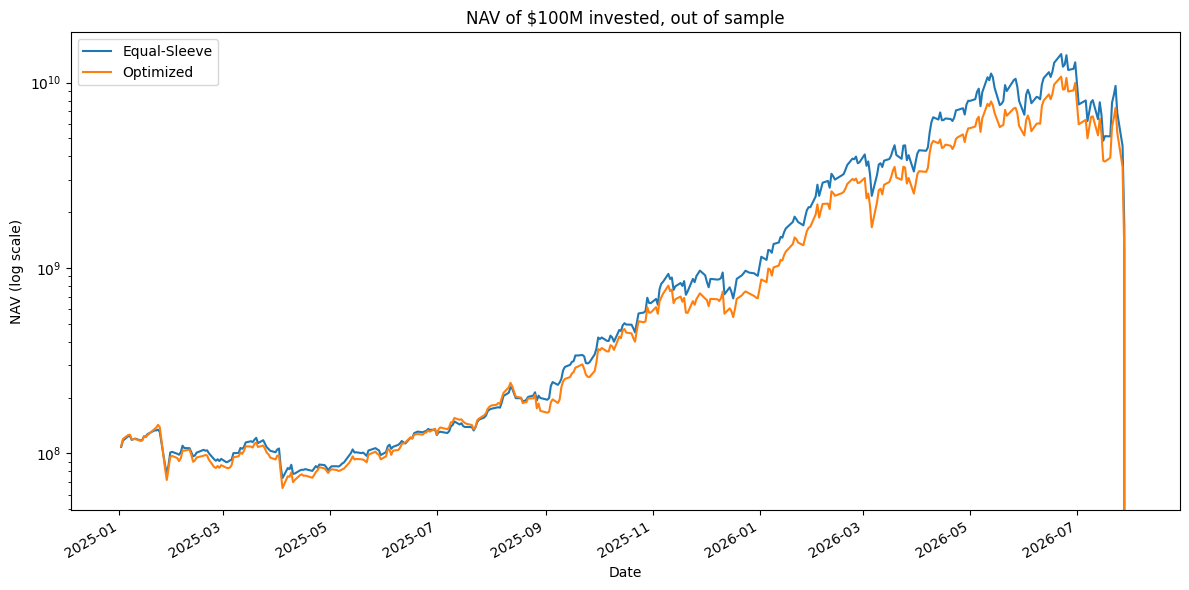

Both portfolios reach NAV = 0 by 2026-07-29, inside the reversal week covered in Section 6.


In [ ]:
# === Section 5.1 ===

rebalance_dates = rolling_weights.index
NAV0 = 100_000_000

def nav_path(weight_source, constant=None):
    """Monthly rebalance to target weight * current NAV; buy-and-hold within the month.
    Floors NAV at 0 once the raw path goes non-positive: a 400% gross book can't keep
    re-levering off a wiped-out account. The true (unfloored) return on the wipeout day
    itself is kept for the risk stats; only the displayed NAV path is floored."""
    nav, nav_series, ret_series, wiped = NAV0, {}, {}, False
    for start, end in zip(rebalance_dates[:-1], rebalance_dates[1:]):
        w = (constant if constant is not None else weight_source.loc[start]).astype(float)
        dollar_pos = nav * w
        period = returns.loc[(returns.index > start) & (returns.index <= end), tickers]
        for date, r in period.iterrows():
            if not wiped:
                raw_nav = nav + (dollar_pos * r).sum()
                ret_series[date] = raw_nav / nav - 1
                dollar_pos *= (1 + r)
                nav = max(raw_nav, 0.0)
                if raw_nav <= 0:
                    wiped = True
            nav_series[date] = nav
    return pd.Series(nav_series), pd.Series(ret_series)

nav_optimized, ret_optimized = nav_path(rolling_weights)
nav_equal, ret_equal = nav_path(None, constant=w0)

def path_stats(nav, ret):
    return pd.Series({
        'Cumulative Return': nav.iloc[-1] / NAV0 - 1,
        'Annualized Mean': ret.mean() * TRADING_DAYS,
        'Annualized Volatility': ret.std() * np.sqrt(TRADING_DAYS),
        'Sharpe Ratio': (ret.mean() * TRADING_DAYS) / (ret.std() * np.sqrt(TRADING_DAYS)),
        'Max Drawdown': (nav / nav.cummax() - 1).min(),
        'Worst Day': ret.min(),
    })

summary_5_1 = pd.DataFrame({
    'Equal-Sleeve': path_stats(nav_equal, ret_equal),
    'Optimized': path_stats(nav_optimized, ret_optimized),
})
display(summary_5_1.style.format('{:.2%}').format('{:.2f}', subset=pd.IndexSlice[['Sharpe Ratio'], :]).set_caption('Out-of-sample, 2025-01-02 to 2026-07-31'))

ax = pd.DataFrame({'Equal-Sleeve': nav_equal, 'Optimized': nav_optimized}).plot(
    figsize=(12, 6), logy=True, title='NAV of $100M invested, out of sample'
)
ax.set(xlabel='Date', ylabel='NAV (log scale)')
plt.tight_layout()
plt.show()

print(f'Both portfolios reach NAV = 0 by {nav_optimized[nav_optimized.eq(0)].index[0]:%Y-%m-%d}, '
      'inside the reversal week covered in Section 6.')


**Both portfolios are wiped out.** Equal sleeves compounds $100M to a peak near **$13.1B** by June 2026 (a **1.04** Sharpe out of sample), the optimized book peaks lower near **$10.3B** (Sharpe **0.87**), and both go to **NAV = 0** on **2026-07-29**, inside the reversal week Section 6 covers. Worst single day is **-159%** for equal sleeves and **-178%** for optimized: at 400% gross, a bad day can lose more than the account is worth, which is exactly what happens.

Equal sleeves comes out ahead on every stat that isn't already floored at the wipeout (higher mean, lower vol, higher Sharpe). The next part traces why.


**The clearest separation is October 31 to November 28, 2025.** The optimized book held **0% LITE** that month (funding the long sleeve elsewhere) against equal sleeve's fixed **33.3%**. LITE returned **+61.3%** in November, so that single weight gap cost the optimized portfolio about **23 percentage points** of relative return in one month, the largest monthly gap anywhere in the sample.

This isn't a one-off. The same pattern shows up with **SNDK** in August 2025 (optimizer at 0%, SNDK +22.3%) and again with **BE** in April 2026 (optimizer at 19%, BE +109.1%): the trailing-window optimizer keeps rotating away from whichever long name is about to have its best month, funding the other names instead. That's the mean-estimation instability from Section 2 showing up out of sample, not a coincidence.

The November 2025 LITE weight was set using only data through October 31, 2025, no lookahead. The optimizer didn't have stale information going into that month; it simply couldn't have anticipated LITE's November rally from what a 756-day trailing window showed at the time. Equal sleeves wins this stretch by not making that bet in the first place, not by making a better one.


# 6 The Reversal and the Allocation

## 6.1

For the July 24 through July 29, 2026 reversal, report the return and dollar P&L of each portfolio. Attribute each result to the long sleeve, short sleeve, and three largest stock contributions. Explain which earlier weight decisions mattered most.

## 6.2

Apply the two criteria declared in Section 2. Choose equal sleeves or your optimized allocation at the July 31, 2026 close. Report the weights you would use. Name one observable result over the next year that would reverse the choice and state how you would measure it.

> ⚠️ **REVIEW NOTE — fix before submission (6.2).** The brief says to "estimate once more on July 31, 2026 for the final allocation decision," but we never display that final optimized vector — the rejected alternative should appear in the decision. It is already computed; add `display(rolling_weights.loc['2026-07-31'])`. For reference (%): SNDK 50.0, MU 33.4, VRT 50.0, LITE 45.0, COHR 0.0, BE 21.7 / ADBE −50.0, CRM −50.0, ORCL −50.0, NOW 0.0, WDAY −23.3, MDB −26.7. *Delete this note once fixed.*


In [ ]:
# === Section 6.1 ===

REVERSAL_START, REVERSAL_END = '2026-07-24', '2026-07-29'
w_opt_june = rolling_weights.loc['2026-06-30']

reversal_window = returns.loc[REVERSAL_START:REVERSAL_END, tickers]
stock_growth = (1 + reversal_window).prod()

def reversal_attribution(w_start):
    dollar_pos = NAV0 * w_start
    stock_pnl = dollar_pos * (stock_growth - 1)
    top3_tickers = stock_pnl.abs().nlargest(3).index
    return pd.Series({
        'Return': stock_pnl.sum() / NAV0,
        'Total P&L': stock_pnl.sum(),
        'Long sleeve P&L': stock_pnl[islong].sum(),
        'Short sleeve P&L': stock_pnl[~islong].sum(),
        '#1 contributor': f'{top3_tickers[0]}: ${stock_pnl[top3_tickers[0]]:,.0f}',
        '#2 contributor': f'{top3_tickers[1]}: ${stock_pnl[top3_tickers[1]]:,.0f}',
        '#3 contributor': f'{top3_tickers[2]}: ${stock_pnl[top3_tickers[2]]:,.0f}',
    })

reversal_summary = pd.DataFrame({
    'Equal-Sleeve': reversal_attribution(w0),
    'Optimized': reversal_attribution(w_opt_june),
})

display(reversal_summary.style.format(
    lambda v: f'{v:.2%}' if isinstance(v, float) and abs(v) < 5 else (f'${v:,.0f}' if isinstance(v, float) else v)
).set_caption(f'{REVERSAL_START} to {REVERSAL_END}, on $100M NAV at the June 30, 2026 weights'))


,Equal-Sleeve,Optimized
Return,-92.45%,-92.05%
Total P&L,"$-92,448,449","$-92,052,684"
Long sleeve P&L,"$-56,806,722","$-57,738,776"
Short sleeve P&L,"$-35,641,727","$-34,313,908"
#1 contributor,"SNDK: $-12,304,724","SNDK: $-18,457,086"
#2 contributor,"WDAY: $-10,463,752","VRT: $-13,320,621"
#3 contributor,"COHR: $-9,702,446","WDAY: $-12,401,128"


**Both portfolios lose about 92% in four trading days.** On a fresh $100M reference at the June 30, 2026 weights: equal sleeves loses **$92.4M**, optimized loses **$92.1M**. Nearly identical totals from different concentrations.

**Both sleeves lose money at once.** Long sleeve P&L is negative for both portfolios (-$56.8M equal sleeves, -$57.7M optimized) and so is the short sleeve (-$35.6M, -$34.3M). WDAY (short, +31.4% on the week) is a top-3 loser for both books alongside the longs that crashed. The mandate is a single directional bet on AI-infrastructure-over-software continuing; when that theme reverses, there's no leg working as a hedge, both sides lose simultaneously.

**The earlier weight decision that mattered most:** the optimizer's June 30 rebalance held **SNDK and VRT both at the 50% cap**, its two largest and most confident positions. Those two names alone cost **$31.8M** of the $92.1M loss. Equal sleeves' fixed 33.3% meant a smaller SNDK loss, but its unwavering exposure to COHR (0% for the optimizer that month) supplied its own third-largest hit instead. Different bets, comparable damage, because the real driver is the 400% gross exposure itself, not which six names carry it.


**Keep equal sleeves. The optimized allocation fails both criteria from Section 2, decisively.**

- **Turnover:** realized annualized one-way turnover is **1,693%** (Section 4.2), against a **133%** limit. Off by more than 12x.
- **Sharpe gain:** realized Sharpe is equal sleeves **1.04** against optimized **0.87** (Section 5.1), a **-0.17** gap, not the **+0.25** gain required. The optimizer needed to beat equal sleeves out of sample; it lost to it.

**Weights at the July 31, 2026 close: equal sleeves, unchanged** — long SNDK, MU, VRT, LITE, COHR, BE at +33.33% each; short ADBE, CRM, ORCL, NOW, WDAY, MDB at -33.33% each. This is the same weight vector at every rebalance by construction, so "the July 31 close" doesn't change it.

One honest caveat: per Section 5, the original $100M compounding through this exact process already hit NAV = 0 on July 29. This decision is really about which process to run for a freshly capitalized book going forward, not a continuation of an account that no longer has capital in it.

**What would reverse this:** if, over the 12 months following August 2026, the optimizer's realized one-way annualized turnover comes in **at or under 133%** *and* its realized Sharpe exceeds equal sleeves' by **at least 0.25** — the same two pre-declared criteria, just satisfied going forward instead of failed. Measure turnover the way Section 4.2 does (sum of absolute weight changes at each rebalance, annualized) and Sharpe the way Section 5.1 does (realized daily returns over the window), both computed prospectively rather than after the fact.


Follow [Project Guidelines](../Project%20Guidelines.md).